In [1]:
# Install all the dependencies
#%%capture
#%pip -q install diffusers accelerate

In [2]:
import torch
from diffusers import DiffusionPipeline

## hugging face
https://huggingface.co/CompVis/stable-diffusion-v1-4

In [3]:
# Define the Stable Diffusion XL pipeline
pipeline2 = DiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16,
)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

#device = torch.device("cpu")
print("Using Device:", device)
pipeline2 = pipeline2.to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Using Device: mps


In [4]:
# Setting a seed would ensure reproducibility of the experiment.
generator = torch.Generator(device=device).manual_seed(42)

  0%|          | 0/50 [00:00<?, ?it/s]

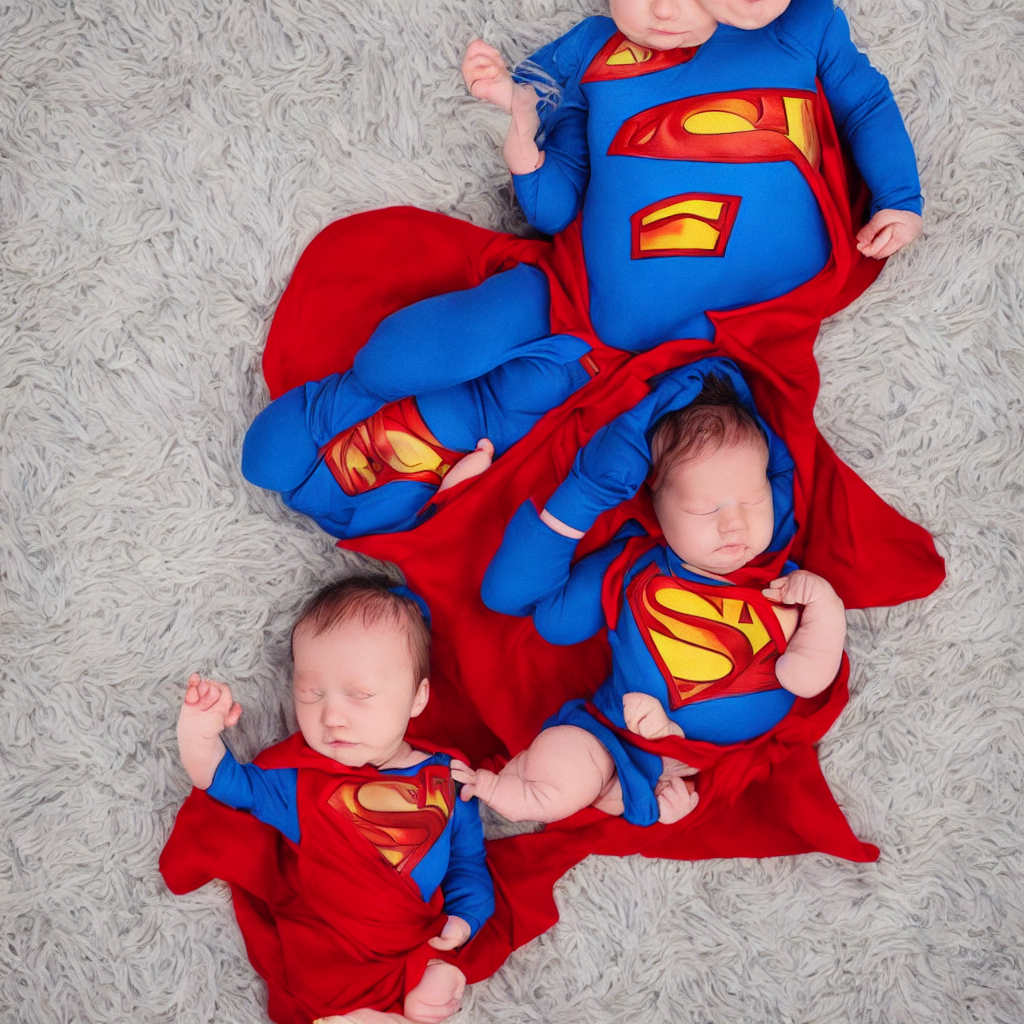

In [5]:
# Set the prompt
prompt = "baby in superman dress"
# Set the negative prompt, or leave it `None` if you don't want to use it
negative_prompt = None
# Add the callback to the pipeline, and execute the pipeline.
image = pipeline2(
    prompt,
    negative_prompt=negative_prompt,
    generator=generator,
    height=1024,
    width=1024,
)
image.images[0]

https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0

In [6]:
# Imports
import torch
from diffusers import DiffusionPipeline


# Define the Stable Diffusion XL pipeline
pipeline = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
)
# Set the device for the pipeline
pipeline = pipeline.to(device)
# uncomment the following line if you encounter OOM issues
# pipeline.enable_sequential_cpu_offload()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [7]:
# Set the prompt
prompt = "baby in superman dress"
# Set the negative prompt, or leave it `None` if you don't want to use it
negative_prompt = None
# Add the callback to the pipeline, and execute the pipeline.
#pipeline.unet = torch.compile(pipeline.unet, mode="reduce-overhead", fullgraph=True)
image = pipeline(
    prompt,
    negative_prompt=negative_prompt,
    generator=generator,
    height=1024,
    width=1024,
)

  0%|          | 0/50 [00:00<?, ?it/s]

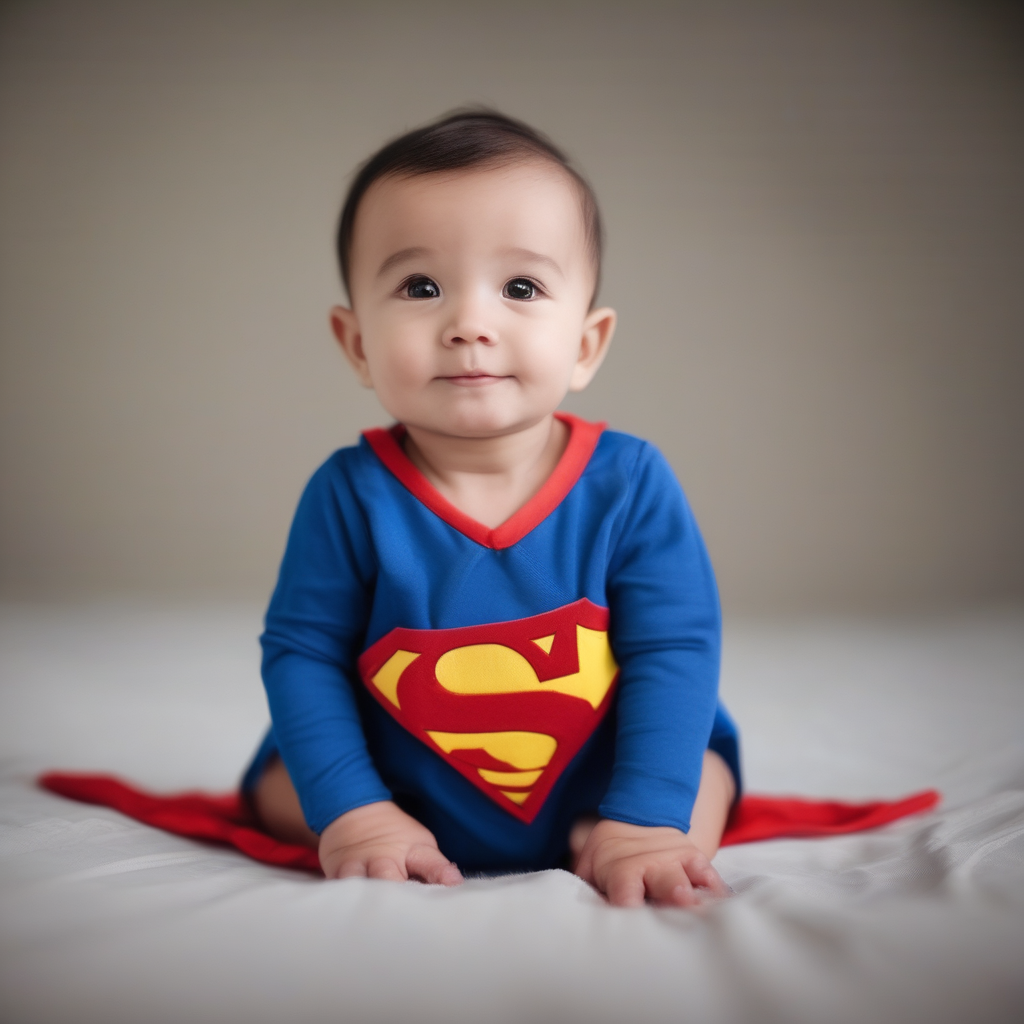

In [8]:
image.images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

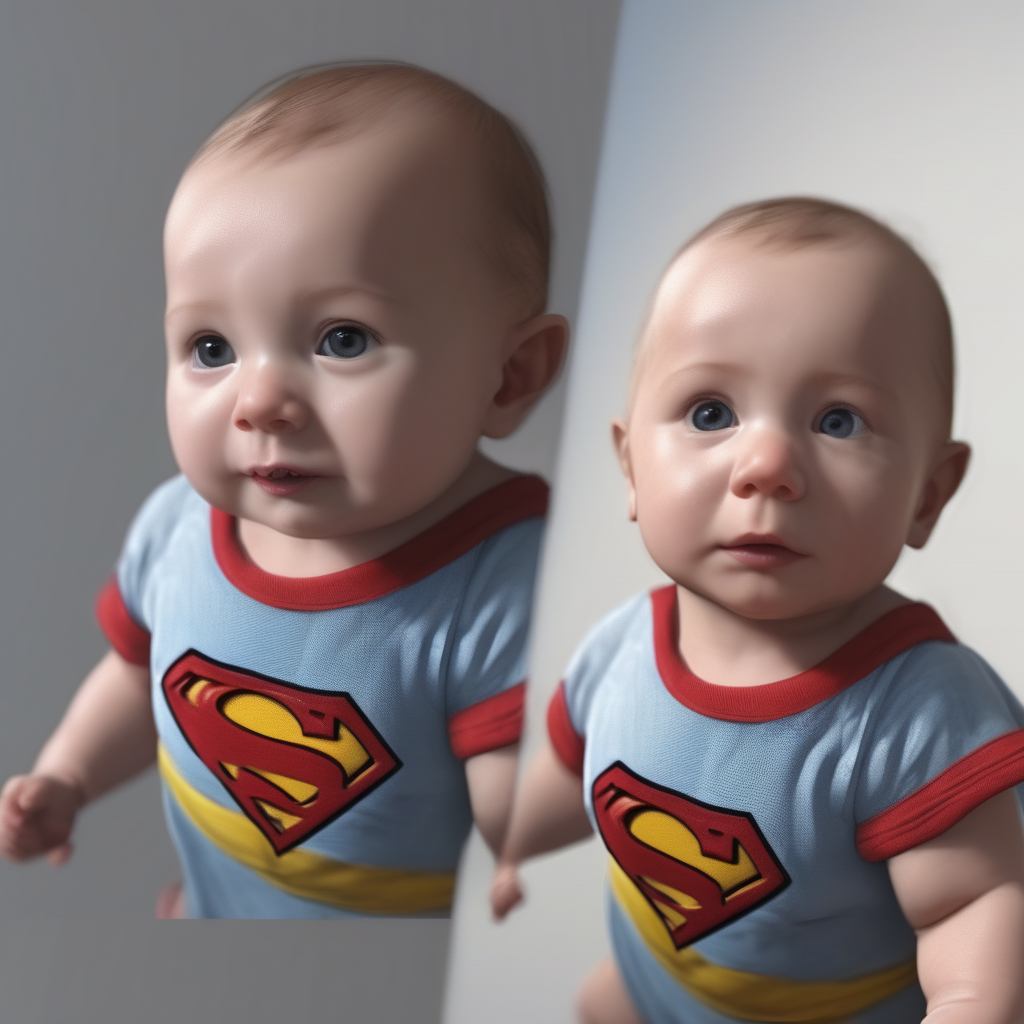

In [ ]:
# Set the prompt
prompt = "baby in superman dress, photorealistic, cinematic, ultra detailed"
# Set the negative prompt, or leave it `None` if you don't want to use it
negative_prompt = None
# Add the callback to the pipeline, and execute the pipeline.

image = pipeline(
    prompt,
    negative_prompt=negative_prompt,
    generator=generator,
    height=1024,
    width=1024,
)
image.images[0]

In [10]:
pipeline

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "stabilityai/stable-diffusion-xl-base-1.0",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [11]:
pipeline2

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "CompVis/stable-diffusion-v1-4",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}